ARTI 450: Deep Learning

Cody & Logan

Professor Gogolin

Fall 2024

# Introduction


The plan is to build a rice classification algorithm using a Convolutional Neural Network. The images are 250 x 250 pixels and there are around 75,000 in total

## Overview

Zipped folder contains 5 folders that each contain many images of a certain type of rice. Images must be labeled and combined into one dataset before partitioning.

In [1]:
# allow access to drive

#from google.colab import drive
#drive.mount('/content/drive')

In [1]:
import zipfile
import os
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import random
from sklearn.model_selection import train_test_split
from matplotlib.gridspec import GridSpec

C:\Users\codyd\AppData\Local\Temp\ipykernel_12228\1608713004.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# extract the zip file to cwd '/content'

ZIPPED = "D:/School/ARTI-450/Project Rice/RiceArchive.zip"

zipfile.ZipFile(ZIPPED).extractall(path='D:/School/ARTI-450/Project Rice')

Should extract a folder "Rice_Image_Dataset" to cwd.

In [2]:
os.chdir('D:/School/ARTI-450/Project Rice/')

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'RiceArchive.zip',
 'RiceClassification.ipynb',
 'Rice_Image_Dataset',
 'Source.gv',
 'testbook.ipynb']

In [4]:
UNZIPED = 'D:/School/ARTI-450/Project Rice/Rice_Image_Dataset'
os.listdir(UNZIPED)

['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

5 Folders each containing images of their respected rice type.

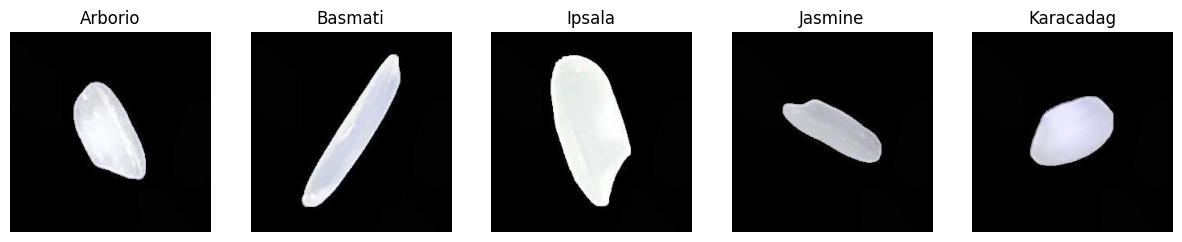

In [5]:
folders = os.listdir(UNZIPED)

# Create a figure to display the images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Display an example image from each folder
for i, folder in enumerate(folders):
    # Get a list of image files in the folder
    image_files = os.listdir(os.path.join(UNZIPED, folder))
    # Select a random image file
    image_file = random.choice(image_files)
    # Load the image
    img = mpimg.imread(os.path.join(UNZIPED, folder, image_file))
    # Display the image
    axes[i].imshow(img)
    axes[i].set_title(folder)
    axes[i].axis('off')

plt.show()

There are 5 types of rice in this image folder.
* Ipsala
* Jasmine
* Arborio
* Karacadag
* Basmati.

If you look closely, each rice type has a different color tint. Since we don't have good compute resources, we will turn the images black and white. If this wasn't the case, RGB would allow for much higher accuracy.

In [6]:
# Images in each class

for folder in folders:
  print(f"{folder}: {len(os.listdir(os.path.join(UNZIPED, folder)))}")

Arborio: 15000
Basmati: 15000
Ipsala: 15000
Jasmine: 15000
Karacadag: 15000


There is 15,000 images of each class.

### Creating DataFrame

*There was much struggle with figuring out a solution to conserve the system RAM so Colab wouldn't crash when reading images from folder.*

**Failed Solutions**



*   Store data in dictionaries
*   Store data in lists
*   Batch Process Folders and Store each to Disk using the to csv method from pandas (data format got messed up everytime)

**Working Solution**

* Create dataframe of each folder using a generator. Create list of dataframes and then combine dataframes.


**Notes**

*  Attempting to standardize the pixel values uses lots of RAM
* Perhaps the problem was in the standardization calculations all along




In [7]:
def dataFrameOfFolder(folders) -> pd.DataFrame:
  """ Generator of dataframe for each folder. """
  for folder in folders:
    imData = []
    labelData = []
    print(f"Doing {folder}")
    imageFolder = os.listdir(os.path.join(UNZIPED, folder))

    for image in imageFolder:
      # read as black and white
      img = cv2.imread((os.path.join(UNZIPED, folder, image)), cv2.IMREAD_GRAYSCALE)
      scaledImg = cv2.resize(img, (50, 50), interpolation=cv2.INTER_AREA)
      imData.append(scaledImg)
      labelData.append(folder)
    df = pd.DataFrame({"Image": imData, "Label": labelData})
    yield (df)

In [8]:
# storing all dataframes of each rice type in list

riceFrames = []

for content in dataFrameOfFolder(folders):
  riceFrames.append(content)

Doing Arborio
Doing Basmati
Doing Ipsala
Doing Jasmine
Doing Karacadag


In [9]:
# concat of all dataframes extracted

masterDf = pd.DataFrame()

for df in riceFrames:
    masterDf = pd.concat([masterDf, df], ignore_index=True)

In [10]:
""" Dictionary for encoding labels """

labelDict = {
    'Ipsala': 0,
    'Jasmine': 1,
    'Arborio': 2,
    'Karacadag': 3,
    'Basmati': 4
}

encodeLabel = lambda label: labelDict[label] # -> int

# test
print(encodeLabel('Arborio'))

2


In [11]:
# Label Encoding
masterDf['Label'] = masterDf['Label'].apply(lambda row: encodeLabel(row))

In [12]:
# taking a peep

masterDf.sample(10)

,Image,Label
40306,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
45274,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1
73734,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3
14922,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2
66353,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3
68597,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3
27533,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4
14096,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2
38802,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0
59183,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1


In [18]:
masterDf["Image"] = masterDf["Image"].apply(lambda row: np.stack(row, axis=0))

## Model Build



*   Exporting the dataframe as is to csv doens't work as the image data gets cut off.
*   Setting up the image data to the proper format has yet to work



In [19]:
X = masterDf['Image'].tolist()  # Convert image data column to a list
y = masterDf['Label']

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

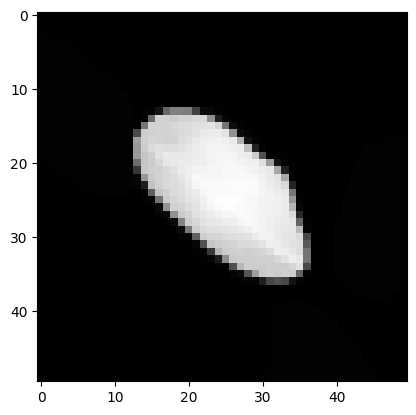

In [20]:
plt.imshow(X_train[0], cmap='gray')

Looks like Karacadag

In [21]:
# Training class split

y_train.value_counts()

Label
3    12071
4    12005
1    12004
2    12003
0    11917
Name: count, dtype: int64

Normalizing the images [0,1] takes too much memory.

In [22]:
# reshaping

X_train = np.stack(X_train, axis=0)
X_test = np.stack(X_test, axis=0)

In [23]:
# adding the extra channel is for the intensity of light since black and white

X_train = X_train.reshape(X_train.shape[0], 250, 250, 1)
X_test = X_test.reshape(X_test.shape[0], 250, 250, 1)

ValueError: cannot reshape array of size 150000000 into shape (60000,250,250,1)

*  Need to convert values to float 32 for neural network. Issues with resources persist.

* Maybe resize images
